## 1. Import Library

In [ ]:
#  Spark . untuk prmrosesan big data
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, rand
from pyspark.sql.functions import sum as spark_sum
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
)
from pyspark.ml import Pipeline

#  Imbalanced-learn & Scikit-learn
from imblearn.over_sampling import ADASYN
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder

# Data & Visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

print("Semua library berhasil di-import.")

Semua library berhasil di-import.


## 2. Inisialisasi Spark Session

gunnaya untuk membuat Spark Session menggunakan SparkSession.builder.#Spark Session diperlukan agar PySpark dapat berjalan dan memproses dataset secara distributed.


In [ ]:
spark = (
    SparkSession.builder
    .appName("RF_ADASYN_CV10Fold_FIXED")
    .config("spark.sql.shuffle.partitions", "50")
    .getOrCreate()
)
print(f"Spark versi {spark.version} aktif.")


Spark versi 4.0.2 aktif.


## 3. Load Dataset

Cell ini digunakan untuk membaca dataset CSV menggunakan Spark. Parameter header=True digunakan agar Spark membaca nama kolom pada baris pertama, sedangkan inferSchema=True membuat Spark otomatis mendeteksi tipe data tiap kolom.

In [ ]:
FILE_PATH = "/content/df_clean.parquet"
df = spark.read.parquet(FILE_PATH)

print("Schema:")
df.printSchema()
print(f"\nTotal baris  : {df.count():,}")
print(f"Total kolom  : {len(df.columns)}")
df.show(5, truncate=False)

Schema:
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- delivery_time: integer (nullable = true)
 |-- is_late: integer (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- is_satisfied: integer (nullable = true)
 |-- total_payment_value: double (nullable = true)
 |-- total_items: long (nullable = true)
 |-- total_price: double (nullable = true)
 |-- total_freight: double (nullable = true)


Total baris  : 95,830
Total kolom  : 11
+--------------------------------+--------------------------------+-------------+-------+--------------+-------------+------------+-------------------+-----------+-----------+-------------+
|order_id                        |customer_id                     |delivery_time|is_late|customer_state|customer_city|is_satisfied|total_payment_value|total_items|total_price|total_freight|
+--------------------------------+--------------------------------+-------------

## 4. Eksplorasi Data (EDA Singkat)

Pada cell ini dilakukan pengecekan null value, distribusi target, dan statistik dasar dataset. Tujuannya untuk memahami kondisi data sebelum proses machine learning dimulai serta mengetahui apakah dataset mengalami class imbalance.

In [ ]:
#  Cek null value
print("Null Value per Kolom:")
null_counts = df.select(
    [spark_sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]
)
null_counts.show()

#  Distribusi target
print("\nDistribusi Target (is_satisfied):")
df.groupBy("is_satisfied").count() \
  .withColumnRenamed("count", "total") \
  .orderBy("is_satisfied") \
  .show()

df.describe().show()

Null Value per Kolom:
+--------+-----------+-------------+-------+--------------+-------------+------------+-------------------+-----------+-----------+-------------+
|order_id|customer_id|delivery_time|is_late|customer_state|customer_city|is_satisfied|total_payment_value|total_items|total_price|total_freight|
+--------+-----------+-------------+-------+--------------+-------------+------------+-------------------+-----------+-----------+-------------+
|       0|          0|            0|      0|             0|            0|           0|                  0|          0|          0|            0|
+--------+-----------+-------------+-------+--------------+-------------+------------+-------------------+-----------+-----------+-------------+


Distribusi Target (is_satisfied):
+------------+-----+
|is_satisfied|total|
+------------+-----+
|           0|20130|
|           1|75700|
+------------+-----+

+-------+--------------------+--------------------+------------------+-------------------+

## 5. Feature Engineering
- `customer_state` diubah ke numerik via **StringIndexer**  
- `customer_city` diabaikan (high-cardinality, >4 000 nilai unik)

untuk menentukan fitur yang dipakai model serta membuat preprocessing pipeline. StringIndexer digunakan untuk mengubah data kategori menjadi angka, sedangkan VectorAssembler menggabungkan seluruh fitur menjadi satu vector karena Spark ML membutuhkan format vector sebagai input model.

In [ ]:
# Kolom fitur
RAW_FEATURE_COLS = [
    "delivery_time",
    "is_late",
    "total_payment_value",
    "total_items",
    "customer_state",   # akan di-index menjadi customer_state_idx
    "total_price",
    "total_freight"
]

# Fitur post-indexing yang masuk ke VectorAssembler
FEATURE_COLS = [
    "delivery_time",
    "is_late",
    "total_payment_value",
    "total_items",
    "customer_state_idx",
    "total_price",
    "total_freight"
]

TARGET_COL  = "is_satisfied"
SEED        = 42
NUM_FOLDS   = 10

# Kolom ID yang tidak boleh masuk ke ADASYN / model
# Definisi di sini (bukan di dalam loop CV) agar konsisten di seluruh notebook
ID_COLS = ["order_id", "customer_id", "customer_city"]

# StringIndexer untuk customer_state
state_indexer = StringIndexer(
    inputCol="customer_state",
    outputCol="customer_state_idx",
    handleInvalid="keep"
)

# VectorAssembler
assembler = VectorAssembler(
    inputCols=FEATURE_COLS,
    outputCol="features"
)

print(f"Fitur mentah  : {RAW_FEATURE_COLS}")
print(f"Fitur pipeline: {FEATURE_COLS}")
print(f"Kolom ID (dikecualikan dari model): {ID_COLS}")

Fitur mentah  : ['delivery_time', 'is_late', 'total_payment_value', 'total_items', 'customer_state', 'total_price', 'total_freight']
Fitur pipeline: ['delivery_time', 'is_late', 'total_payment_value', 'total_items', 'customer_state_idx', 'total_price', 'total_freight']
Kolom ID (dikecualikan dari model): ['order_id', 'customer_id', 'customer_city']


## 6. Helper Functions
Fungsi pembantu: hitung bobot kelas & tambah Gaussian noise

  untuk membuat beberapa fungsi tambahan. Fungsi pertama digunakan untuk menghitung class weight agar model tidak bias terhadap kelas mayoritas. Fungsi kedua digunakan untuk menambahkan Gaussian Noise sehingga data memiliki variasi tambahan dan membantu mengurangi overfitting.

In [ ]:
#  Fungsi Hitung Bobot Kelas
def calculate_class_weights(df_spark, target_col):
    """Hitung class weight balanced dari Spark DataFrame."""
    total_rows = df_spark.count()
    n_classes  = 2
    counts = {
        row[target_col]: row["count"]
        for row in df_spark.groupBy(target_col).count().collect()
    }
    w0 = total_rows / (n_classes * counts[0])
    w1 = total_rows / (n_classes * counts[1])
    return w0, w1


# Fungsi Gaussian Noise
# Noise HANYA diterapkan pada kolom numerik kontinyu.
# is_late (binary 0/1) dan customer_state_idx (categorical) TIDAK dimasukkan.
# noise_level=0.01 bekerja baik jika data sudah di-scale; jika belum, sesuaikan
# per-kolom atau gunakan fraksi dari std deviasi kolom tersebut.
NUMERIC_COLS = [
    "delivery_time",
    "total_payment_value",
    "total_items",
    "total_price",
    "total_freight"
    # TIDAK include: is_late (binary), customer_state_idx (categorical)
]

def add_gaussian_noise(X, cols, noise_level=0.01, seed=SEED):
    """
    Tambah Gaussian noise pada kolom numerik kontinyu untuk augmentasi.
    noise_level adalah fraksi dari std deviasi tiap kolom (relatif),
    sehingga skala noise proporsional terhadap distribusi data.
    """
    rng = np.random.default_rng(seed)
    X_noisy = X.copy()
    valid_cols = [c for c in cols if c in X.columns]
    if valid_cols:
        # untuk Noise relatif terhadap std tiap kolom agar skala proporsional
        stds = X[valid_cols].std().values
        stds = np.where(stds == 0, 1.0, stds)  # hindari noise=0 pada kolom konstan
        noise = rng.normal(0, noise_level, X[valid_cols].shape) * stds
        X_noisy[valid_cols] = X[valid_cols] + noise
    return X_noisy


print("Helper functions siap.")
print(f"Noise akan diterapkan pada: {NUMERIC_COLS}")

Helper functions siap.
Noise akan diterapkan pada: ['delivery_time', 'total_payment_value', 'total_items', 'total_price', 'total_freight']


## 7. Train-Test Split (80:20)

digunakan untuk membagi dataset menjadi training set dan testing set secara stratified dengan rasio 80:20. Sebelum proses split dilakukan, setiap baris data diberikan ID unik menggunakan monotonically_increasing_id() agar data dapat dipetakan kembali setelah proses pembagian menggunakan scikit-learn.

Kolom __row_id dan target kemudian dikonversi ke pandas karena StratifiedShuffleSplit hanya dapat bekerja menggunakan format pandas/numpy. Metode stratified digunakan agar distribusi kelas pada training dan testing tetap seimbang sehingga model tidak bias terhadap kelas mayoritas.

Hasil split berupa daftar row ID training dan testing yang kemudian diubah kembali menjadi Spark DataFrame. Proses filtering dilakukan menggunakan join() sebagai perbaikan dari penggunaan .isin() untuk menghindari potensi Out Of Memory (OOM) pada dataset besar.

Selanjutnya dilakukan perhitungan class weight hanya pada training set menggunakan fungsi calculate_class_weights(). Bobot kelas ini digunakan untuk membantu model memberikan perhatian lebih pada kelas minoritas selama proses training.

In [ ]:
from pyspark.sql.functions import monotonically_increasing_id

df_indexed = df.withColumn("__row_id", monotonically_increasing_id())

# Ambil label ke Pandas untuk stratified split
pdf_ids = df_indexed.select("__row_id", TARGET_COL).toPandas()

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(sss.split(pdf_ids, pdf_ids[TARGET_COL]))

train_row_ids = pdf_ids.iloc[train_idx]["__row_id"].tolist()
test_row_ids  = pdf_ids.iloc[test_idx]["__row_id"].tolist()

# untukMengatasi potensi OOM dengan .isin() pada list besar
# Menggunakan join dengan Spark DataFrame yang berisi row IDs untuk filtering yang lebih scalable.
train_ids_spark = spark.createDataFrame(pd.DataFrame({"__row_id": train_row_ids}))
test_ids_spark  = spark.createDataFrame(pd.DataFrame({"__row_id": test_row_ids}))

train_df_spark = df_indexed.join(train_ids_spark, on="__row_id", how="inner").drop("__row_id")
test_df_spark  = df_indexed.join(test_ids_spark, on="__row_id", how="inner").drop("__row_id")

#  Hitung bobot HANYA dari data training
weight_0, weight_1 = calculate_class_weights(train_df_spark, TARGET_COL)

train_df_weighted = train_df_spark.withColumn(
    "class_weight",
    when(col(TARGET_COL) == 0, weight_0).otherwise(weight_1)
)

n_train = train_df_spark.count()
n_test  = test_df_spark.count()
print("Dataset Split Stratified (80:20):")
print(f"  Training set : {n_train:,} baris ({n_train/(n_train+n_test)*100:.1f}%)")
print(f"  Test set     : {n_test:,}  baris ({n_test/(n_train+n_test)*100:.1f}%)")
print(f"  Bobot Kelas Training -> Class 0: {weight_0:.4f}, Class 1: {weight_1:.4f}")

# Verifikasi distribusi kelas
print("\nDistribusi kelas – Training:")
train_df_spark.groupBy(TARGET_COL).count().orderBy(TARGET_COL).show()
print("Distribusi kelas – Test:")
test_df_spark.groupBy(TARGET_COL).count().orderBy(TARGET_COL).show()

Dataset Split Stratified (80:20):
  Training set : 76,664 baris (80.0%)
  Test set     : 19,166  baris (20.0%)
  Bobot Kelas Training -> Class 0: 2.3803, Class 1: 0.6330

Distribusi kelas – Training:
+------------+-----+
|is_satisfied|count|
+------------+-----+
|           0|16104|
|           1|60560|
+------------+-----+

Distribusi kelas – Test:
+------------+-----+
|is_satisfied|count|
+------------+-----+
|           0| 4026|
|           1|15140|
+------------+-----+



## 8. Fit StringIndexer pada Training Set
Indexer di-fit **sekali** dari data training agar mapping kategori konsisten di seluruh pipeline (CV + Final + Test).

digunakan untuk melakukan proses fitting pada StringIndexer menggunakan seluruh data training yang sudah diberi class weight. Proses fit dilakukan di luar loop cross validation agar mapping kategori tetap konsisten pada seluruh fold dan test set.

Pada bagian ini, state_indexer.fit(train_df_weighted) digunakan untuk mempelajari seluruh kategori pada kolom kategorikal dan mengubahnya menjadi indeks numerik. Hasil fitting kemudian disimpan ke dalam variabel fitted_indexer.

Selain itu dibuat juga alias train_df_prepared yang nantinya digunakan pada proses cross validation agar penamaan dataframe lebih konsisten.

In [ ]:
# Fit StringIndexer dari FULL training set
# Fit di sini (bukan di dalam loop CV) untuk mencegah label leakage
# dan menjamin mapping indeks identik di semua fold + test set.
fitted_indexer = state_indexer.fit(train_df_weighted)

train_df_prepared = train_df_weighted  # alias, digunakan di CV

print(f"StringIndexer di-fit. Jumlah kategori: {len(fitted_indexer.labels)}")
print(f"Contoh mapping (5 pertama): {fitted_indexer.labels[:5]}")

StringIndexer di-fit. Jumlah kategori: 27
Contoh mapping (5 pertama): ['SP', 'RJ', 'MG', 'RS', 'PR']


digunakan untuk mengambil hasil mapping kategori dari StringIndexer yang sudah di-fit sebelumnya. Label kategori disimpan menggunakan fitted_indexer.labels agar urutan encoding tetap konsisten selama proses training dan testing.

In [ ]:
global_state_labels = fitted_indexer.labels

# Create a dictionary for consistent mapping
global_state_to_int = {state: i for i, state in enumerate(global_state_labels)}


## 9. Definisi Model
**Catatan penting:** Objek `rf_model` di sini hanya sebagai template konfigurasi.
Di setiap fold CV dan Final Training, `RandomForestClassifier` di-instantiate ulang
agar state-nya benar-benar bersih (FIX #2 & #3).

digunakan untuk menyimpan parameter utama Random Forest dalam bentuk dictionary. Parameter tersebut nantinya digunakan kembali saat proses cross validation dan final training.

Beberapa parameter yang digunakan antara lain featuresCol sebagai kolom fitur input, labelCol sebagai target prediksi, numTrees untuk menentukan jumlah decision tree, dan maxDepth untuk mengatur kedalaman maksimum tree.

Selain itu digunakan juga weightCol agar model dapat mempertimbangkan class weight selama training sehingga lebih baik dalam menangani data imbalance.

Parameter seed digunakan agar hasil training tetap reproducible dan konsisten setiap kali notebook dijalankan.


In [ ]:
#  Konfigurasi model (template, bukan instance final)
RF_PARAMS = dict(
    featuresCol="features",
    labelCol=TARGET_COL,
    numTrees=100,
    maxDepth=10,
    seed=SEED,
    weightCol="class_weight"
)

# #2: Variabel `pipeline` dihapus — tidak ada pipeline tunggal global.
# Pipeline dibuat fresh di setiap fold dan di final training.
# Ini mencegah reuse objek Spark ML yang bisa membawa state antar-iterasi.

def make_pipeline():
    """Buat pipeline baru dengan RF yang di-instantiate ulang (fresh)."""
    rf = RandomForestClassifier(**RF_PARAMS)
    return Pipeline(stages=[fitted_indexer, assembler, rf])

print("Konfigurasi RF dan fungsi make_pipeline() siap.")
print(f"RF Params: numTrees={RF_PARAMS['numTrees']}, maxDepth={RF_PARAMS['maxDepth']}")

Konfigurasi RF dan fungsi make_pipeline() siap.
RF Params: numTrees=100, maxDepth=10


## 10. Persiapan Evaluator

digunakan untuk membuat evaluator yang akan menghitung performa model selama cross validation dan testing.

MulticlassClassificationEvaluator digunakan untuk menghitung accuracy, precision, recall, dan F1-score, sedangkan BinaryClassificationEvaluator digunakan untuk menghitung AUC-ROC.

Setiap evaluator disimpan dalam variabel berbeda agar lebih mudah dipanggil saat proses evaluasi model berlangsung.

Penggunaan beberapa metrik evaluasi penting karena accuracy saja belum cukup untuk menilai performa model pada dataset imbalance.

In [ ]:
# Definisi Evaluator (sekali, digunakan di CV & Test)
#eval_precision dan eval_recall TIDAK di-redefine di Section 13.
# Definisi tunggal di sini untuk menghindari konflik state.
eval_accuracy  = MulticlassClassificationEvaluator(
    labelCol=TARGET_COL, predictionCol="prediction", metricName="accuracy")
eval_f1        = MulticlassClassificationEvaluator(
    labelCol=TARGET_COL, predictionCol="prediction", metricName="f1")
eval_precision = MulticlassClassificationEvaluator(
    labelCol=TARGET_COL, predictionCol="prediction", metricName="weightedPrecision")
eval_recall    = MulticlassClassificationEvaluator(
    labelCol=TARGET_COL, predictionCol="prediction", metricName="weightedRecall")
eval_auc       = BinaryClassificationEvaluator(
    labelCol=TARGET_COL, rawPredictionCol="rawPrediction", metricName="areaUnderROC")

print("Semua evaluator siap. Tidak akan di-redefine di section manapun.")

Semua evaluator siap. Tidak akan di-redefine di section manapun.


## 11. Manual 10-Fold Stratified Cross Validation
Setiap fold menampilkan: **Accuracy, F1-Score, Precision, Recall, AUC-ROC**




ini merupakan inti utama notebook karena seluruh proses cross validation dilakukan di sini.

Pertama, training dataframe dikonversi ke pandas agar dapat digunakan oleh StratifiedKFold dan ADASYN yang lebih kompatibel dengan format pandas/scikit-learn.

StratifiedKFold digunakan untuk membagi data menjadi 10 fold dengan distribusi kelas yang tetap seimbang pada setiap fold. Pada setiap iterasi, 9 fold digunakan untuk training dan 1 fold digunakan untuk validation.

Selanjutnya dilakukan preprocessing menggunakan fitted_indexer dan VectorAssembler agar data siap digunakan oleh Random Forest.

ADASYN kemudian diterapkan hanya pada training fold untuk menghasilkan synthetic sample pada kelas minoritas. Setelah itu Gaussian Noise ditambahkan untuk memberikan variasi tambahan pada data sehingga membantu mengurangi overfitting.

Data hasil augmentasi kemudian dikonversi kembali menjadi Spark DataFrame sebelum digunakan untuk melatih model Random Forest.

Setelah model selesai dilatih, dilakukan prediksi pada validation fold dan dihitung berbagai metrik evaluasi seperti accuracy, precision, recall, F1-score, dan AUC.

Seluruh hasil evaluasi tiap fold disimpan ke dalam list agar nantinya dapat dihitung rata-rata performanya.

In [ ]:
import numpy as np

# Persiapan Data
pdf_full_train = train_df_spark.toPandas()
X_all = pdf_full_train.drop(columns=[TARGET_COL])
y_all = pdf_full_train[TARGET_COL]


skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)

fold_metrics = []
print(f"Memulai {NUM_FOLDS}-Fold Stratified CV: ADASYN + Dynamic Class Weighting...\n")

for i, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all)):
    #  1. Pisahkan fold
    df_f_train_raw = X_all.iloc[train_idx].copy()
    df_f_train_raw[TARGET_COL] = y_all.iloc[train_idx].values

    df_f_val = X_all.iloc[val_idx].copy()
    df_f_val[TARGET_COL] = y_all.iloc[val_idx].values
    # CATATAN df_f_val memuat customer_state sebagai STRING asli.
    # fitted_indexer di dalam fold_pipeline akan mengubahnya ke float index.

    #  2. Encode customer_state untuk training fold (CONSISTENSI DENGAN fitted_indexer)
    #  Gunakan mapping dari global_state_to_int untuk konsistensi.
    df_f_train_raw['customer_state'] = df_f_train_raw['customer_state'].map(global_state_to_int)

    # 3. Siapkan fitur numerik untuk ADASYN
    # Hapus kolom ID dan target; sisa adalah fitur yang masuk ADASYN
    X_f_numeric = df_f_train_raw.drop(
        columns=[TARGET_COL] + [c for c in ID_COLS if c in df_f_train_raw.columns]
    )

    # 4. Gaussian Noise pada kolom kontinyu
    X_f_noisy = add_gaussian_noise(X_f_numeric, NUMERIC_COLS, seed=SEED + i)

    #  5. ADASYN oversampling
    ada_fold = ADASYN(random_state=SEED)
    X_f_res, y_f_res = ada_fold.fit_resample(X_f_noisy, df_f_train_raw[TARGET_COL])

    #  6. Hitung bobot kelas dari data yang sudah di-resample
    unique, counts = np.unique(y_f_res, return_counts=True)
    total_res = len(y_f_res)
    w_map = {cls: total_res / (2 * count) for cls, count in zip(unique, counts)}

    #  7. Decode customer_state kembali ke string
    pdf_aug = pd.DataFrame(X_f_res, columns=X_f_noisy.columns)
    # FIX for is_late: Round interpolated binary feature back to 0 or 1
    pdf_aug['is_late'] = pdf_aug['is_late'].round().astype(int)

    # ADASYN menginterpolasi nilai float; clip ke range valid sebelum
    # inverse_transform untuk mencegah IndexError.
    state_idx_clipped = np.clip(
        pdf_aug['customer_state'].round().astype(int),
        0, len(global_state_labels) - 1
    )
    # Gunakan global_state_labels sebagai lookup array untuk decoding
    # Convert Series to numpy array for list indexing
    pdf_aug['customer_state'] = np.array(global_state_labels)[state_idx_clipped.values]
    pdf_aug[TARGET_COL]       = y_f_res
    pdf_aug["class_weight"]   = pdf_aug[TARGET_COL].map(w_map)

    # 8. Buat Spark DF & Train
    spark_fold_train = spark.createDataFrame(pdf_aug)
    spark_fold_val   = spark.createDataFrame(df_f_val)  # string customer_state

    # make_pipeline() membuat RF baru setiap fold — tidak reuse objek lama
    fold_pipeline = make_pipeline()
    fold_model    = fold_pipeline.fit(spark_fold_train)
    fold_preds    = fold_model.transform(spark_fold_val)

    #  9. Evaluasi
    acc = eval_accuracy.evaluate(fold_preds)
    f1  = eval_f1.evaluate(fold_preds)
    pre = eval_precision.evaluate(fold_preds)
    rec = eval_recall.evaluate(fold_preds)
    auc = eval_auc.evaluate(fold_preds)

    fold_metrics.append({
        "Fold"     : i + 1,
        "Accuracy" : round(acc, 4),
        "F1-Score" : round(f1,  4),
        "Precision": round(pre, 4),
        "Recall"   : round(rec, 4),
        "AUC-ROC"  : round(auc, 4)
    })
    print(f"  Fold {i+1:2d} │ Acc={acc:.4f}  F1={f1:.4f}  Pre={pre:.4f}  Rec={rec:.4f}  AUC={auc:.4f}")

cv_df = pd.DataFrame(fold_metrics)
display(cv_df)


Memulai 10-Fold Stratified CV: ADASYN + Dynamic Class Weighting...

  Fold  1 │ Acc=0.7200  F1=0.7360  Pre=0.7623  Rec=0.7200  AUC=0.6920
  Fold  2 │ Acc=0.7034  F1=0.7218  Pre=0.7528  Rec=0.7034  AUC=0.6852
  Fold  3 │ Acc=0.7149  F1=0.7319  Pre=0.7605  Rec=0.7149  AUC=0.6957
  Fold  4 │ Acc=0.7210  F1=0.7348  Pre=0.7556  Rec=0.7210  AUC=0.6813
  Fold  5 │ Acc=0.7291  F1=0.7429  Pre=0.7646  Rec=0.7291  AUC=0.6986
  Fold  6 │ Acc=0.7225  F1=0.7363  Pre=0.7572  Rec=0.7225  AUC=0.6928
  Fold  7 │ Acc=0.7198  F1=0.7342  Pre=0.7563  Rec=0.7198  AUC=0.6860
  Fold  8 │ Acc=0.7129  F1=0.7284  Pre=0.7525  Rec=0.7129  AUC=0.6860
  Fold  9 │ Acc=0.7188  F1=0.7344  Pre=0.7596  Rec=0.7188  AUC=0.6912
  Fold 10 │ Acc=0.7197  F1=0.7345  Pre=0.7578  Rec=0.7197  AUC=0.6886


,Fold,Accuracy,F1-Score,Precision,Recall,AUC-ROC
0,1,0.7200,0.7360,0.7623,0.7200,0.6920
1,2,0.7034,0.7218,0.7528,0.7034,0.6852
2,3,0.7149,0.7319,0.7605,0.7149,0.6957
3,4,0.7210,0.7348,0.7556,0.7210,0.6813
4,5,0.7291,0.7429,0.7646,0.7291,0.6986
5,6,0.7225,0.7363,0.7572,0.7225,0.6928
6,7,0.7198,0.7342,0.7563,0.7198,0.6860
7,8,0.7129,0.7284,0.7525,0.7129,0.6860
8,9,0.7188,0.7344,0.7596,0.7188,0.6912
9,10,0.7197,0.7345,0.7578,0.7197,0.6886


## 12. Visualisasi Hasil Cross Validation

untuk membuat grafik performa model berdasarkan hasil cross validation.

Visualisasi dibuat menggunakan matplotlib dan seaborn untuk menampilkan rata-rata nilai accuracy, precision, recall, F1-score, dan AUC dari seluruh fold.

Grafik ini membantu mempermudah interpretasi performa model dan melihat apakah hasil evaluasi cukup stabil.

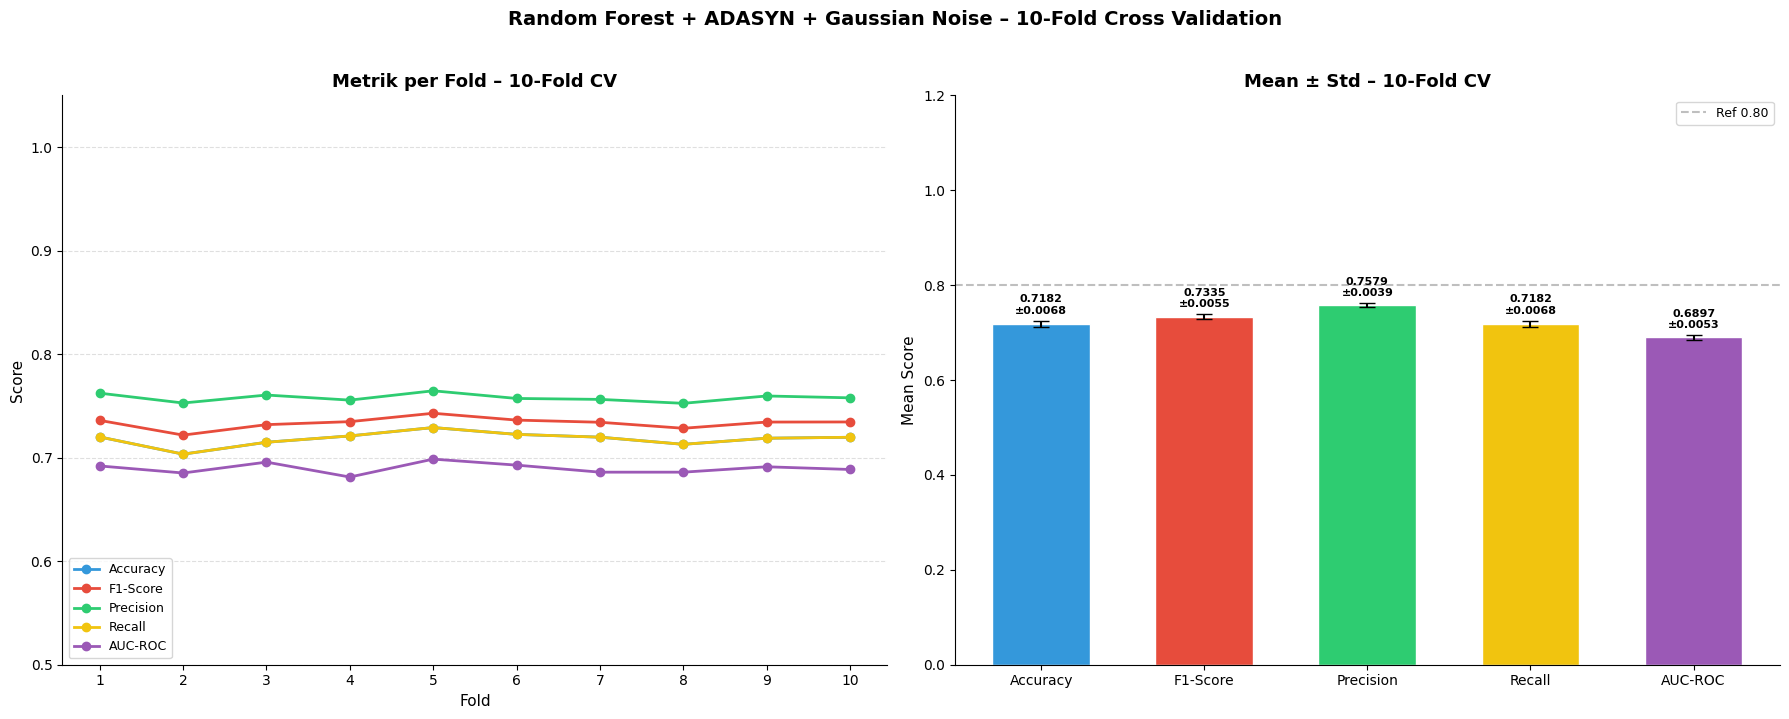

In [ ]:
METRICS       = ["Accuracy", "F1-Score", "Precision", "Recall", "AUC-ROC"]
METRIC_COLORS = ["#3498DB", "#E74C3C", "#2ECC71", "#F1C40F", "#9B59B6"]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Line chart per fold
ax1 = axes[0]
for metric, color in zip(METRICS, METRIC_COLORS):
    ax1.plot(cv_df["Fold"], cv_df[metric],
             marker="o", label=metric, color=color,
             linewidth=2, markersize=6)

ax1.set_xticks(cv_df["Fold"])
ax1.set_xlabel("Fold", fontsize=11)
ax1.set_ylabel("Score", fontsize=11)
ax1.set_ylim(0.5, 1.05)
ax1.set_title("Metrik per Fold – 10-Fold CV", fontsize=13, fontweight="bold")
ax1.legend(fontsize=9, loc='lower left')
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.spines[["top", "right"]].set_visible(False)

#  Plot 2: Bar chart mean ± std
ax2   = axes[1]
means = [cv_df[m].mean() for m in METRICS]
stds  = [cv_df[m].std()  for m in METRICS]

bars = ax2.bar(METRICS, means, color=METRIC_COLORS,
               yerr=stds, capsize=6, width=0.6, edgecolor="white")

for bar, mean, std in zip(bars, means, stds):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + std + 0.01,
        f"{mean:.4f}\n±{std:.4f}",
        ha="center", va="bottom", fontsize=8, fontweight="bold"
    )

ax2.set_ylim(0, 1.2)
ax2.axhline(y=0.8, color="gray", linestyle="--", alpha=0.5, label="Ref 0.80")
ax2.set_ylabel("Mean Score", fontsize=11)
ax2.set_title("Mean ± Std – 10-Fold CV", fontsize=13, fontweight="bold")
ax2.legend(fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)

plt.suptitle(
    "Random Forest + ADASYN + Gaussian Noise – 10-Fold Cross Validation",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("cv_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

### 12b. Visualisasi Pembagian Fold (StratifiedKFold)

digunakan untuk memvisualisasikan bagaimana data dibagi pada setiap fold cross validation.

Visualisasi dibuat agar proses pembagian training dan validation lebih mudah dipahami serta membuktikan bahwa seluruh data mendapatkan giliran menjadi validation set.

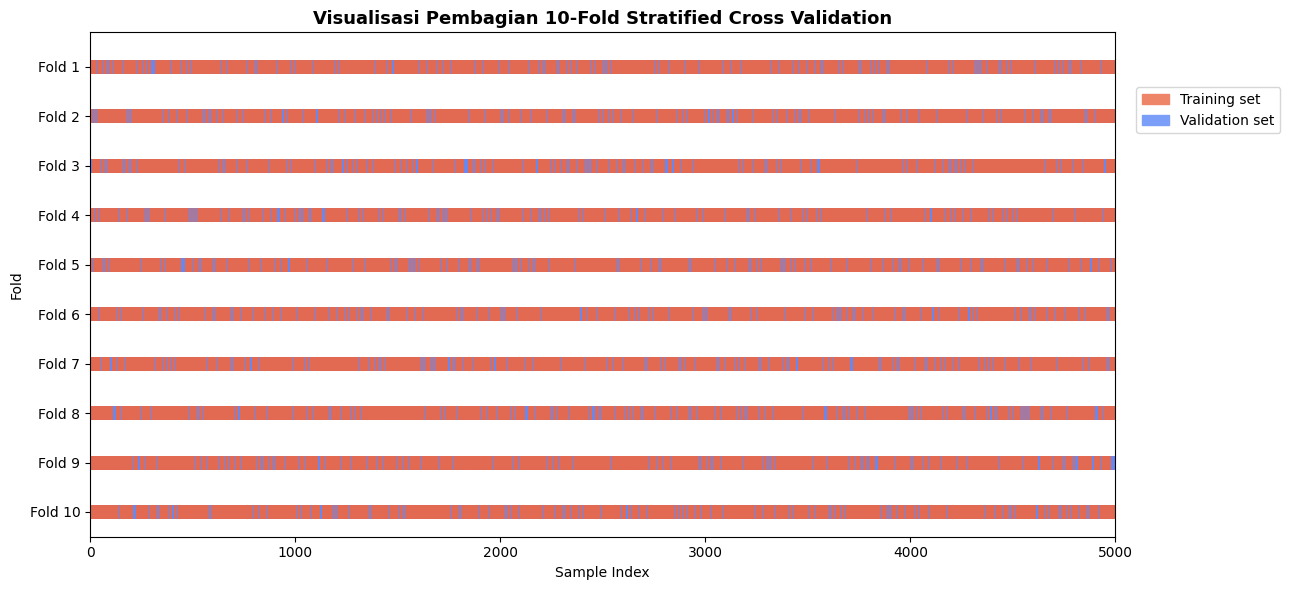

In [ ]:
def plot_cv_indices(cv_splitter, X, y, ax, n_splits, lw=10):
    """Visualisasi indeks Train/Val tiap fold."""
    cmap = plt.cm.coolwarm
    for ii, (tr, tt) in enumerate(cv_splitter.split(X, y)):
        indices      = np.full(len(X), np.nan)
        indices[tr]  = 1
        indices[tt]  = 0
        ax.scatter(
            range(len(indices)), [ii + 0.5] * len(indices),
            c=indices, marker="_", lw=lw,
            cmap=cmap, vmin=-0.2, vmax=1.2
        )
    ax.set(
        yticks=np.arange(n_splits) + 0.5,
        yticklabels=[f"Fold {i+1}" for i in range(n_splits)],
        xlabel="Sample Index", ylabel="Fold",
        ylim=[n_splits, -0.2], xlim=[0, len(X)]
    )
    ax.legend(
        [mpatches.Patch(color=cmap(0.8)), mpatches.Patch(color=cmap(0.2))],
        ["Training set", "Validation set"],
        loc=(1.02, 0.8)
    )

# Terapkan fitted_indexer agar customer_state_idx tersedia untuk visualisasi
pdf_vis = fitted_indexer.transform(train_df_prepared.limit(5000)).toPandas()
X_vis   = pdf_vis[FEATURE_COLS]
y_vis   = pdf_vis[TARGET_COL]

fig, ax = plt.subplots(figsize=(13, 6))
plot_cv_indices(skf, X_vis, y_vis, ax, NUM_FOLDS)
ax.set_title(f"Visualisasi Pembagian {NUM_FOLDS}-Fold Stratified Cross Validation",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("cv_split_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Training Model Final
Train pada seluruh data training (augment dengan ADASYN + Gaussian Noise)

untuk melatih model final menggunakan seluruh training set setelah proses cross validation selesai.

Data training terlebih dahulu diproses menggunakan preprocessing pipeline yang sama seperti pada cross validation. Setelah itu dilakukan ADASYN untuk oversampling kelas minoritas dan penambahan Gaussian Noise untuk augmentasi data.

Model Random Forest kemudian dilatih menggunakan seluruh data training hasil augmentasi agar menghasilkan model final terbaik sebelum evaluasi testing dilakukan.

In [ ]:
print("Melakukan final training dengan full training data + ADASYN...")

# 1. Konversi ke Pandas & Encode customer_state (CONSISTENSI DENGAN fitted_indexer)
pdf_final_raw = train_df_spark.toPandas()
# note: Gunakan mapping dari global_state_to_int untuk konsistensi.
pdf_final_raw['customer_state'] = pdf_final_raw['customer_state'].map(global_state_to_int)

#  2. Drop kolom ID & target sebelum masuk ADASYN
X_final_numeric = pdf_final_raw.drop(
    columns=[TARGET_COL] + [c for c in ID_COLS if c in pdf_final_raw.columns]
)
#  3. Gaussian Noise
X_final_noisy = add_gaussian_noise(X_final_numeric, NUMERIC_COLS, seed=SEED)

#  4. ADASYN oversampling
ada_final = ADASYN(random_state=SEED)
X_final_res, y_final_res = ada_final.fit_resample(X_final_noisy, pdf_final_raw[TARGET_COL])

#  5. Hitung bobot kelas setelah resample
unique_f, counts_f = np.unique(y_final_res, return_counts=True)
total_f = len(y_final_res)
w_map_final = {cls: total_f / (2 * count) for cls, count in zip(unique_f, counts_f)}

#  6. Decode customer_state & susun DataFrame
pdf_final_aug = pd.DataFrame(X_final_res, columns=X_final_noisy.columns)
# for is_late: Round interpolated binary feature back to 0 or 1
pdf_final_aug['is_late'] = pdf_final_aug['is_late'].round().astype(int)

# untuk Clip index ke range valid sebelum inverse_transform
state_idx_clipped_final = np.clip(
    pdf_final_aug['customer_state'].round().astype(int),
    0, len(global_state_labels) - 1
)
# Gunakan global_state_labels sebagai lookup array untuk decoding
# untuk Convert Series to numpy array for list indexing
pdf_final_aug['customer_state'] = np.array(global_state_labels)[state_idx_clipped_final.values]
pdf_final_aug[TARGET_COL]       = y_final_res
pdf_final_aug["class_weight"]   = pdf_final_aug[TARGET_COL].map(w_map_final)

#  7. Kembalikan ke Spark & Fit Pipeline
spark_train_final = spark.createDataFrame(pdf_final_aug)

# make_pipeline() untuk RF baru yang fresh
final_pipeline = make_pipeline()
final_model    = final_pipeline.fit(spark_train_final)

print(f"Model final siap.")
print(f"Distribusi setelah ADASYN: {dict(zip(unique_f.tolist(), counts_f.tolist()))}")
print(f"Bobot kelas: {w_map_final}")


Melakukan final training dengan full training data + ADASYN...
Model final siap.
Distribusi setelah ADASYN: {0: 59152, 1: 60560}
Bobot kelas: {np.int32(0): np.float64(1.011901541790641), np.int32(1): np.float64(0.9883751651254954)}


## 14. Evaluasi pada Test Set

untuk mengevaluasi model final menggunakan testing set yang belum pernah dilihat model sebelumnya.

Testing set diproses menggunakan preprocessing yang sama seperti training namun tanpa ADASYN maupun Gaussian Noise agar tetap merepresentasikan kondisi data asli.

Setelah dilakukan prediksi, notebook menghitung berbagai metrik evaluasi seperti accuracy, precision, recall, F1-score, dan AUC untuk melihat kemampuan generalisasi model.

In [ ]:
#  Evaluasi pada Test Set (Data Asli / Tidak Di-augmentasi)
# test_df_spark adalah 20% data asli yang tidak pernah melihat ADASYN / Noise.
# test_df_spark tidak memiliki kolom 'class_weight' — dan memang
# tidak perlu. weightCol hanya dipakai saat .fit(), bukan .transform().
# Spark ML tidak akan error, tapi penting dipahami agar tidak membingungkan.

predictions = final_model.transform(test_df_spark)

# note: Gunakan evaluator dari Section 10 — TIDAK di-redefine ulang di sini.
accuracy  = eval_accuracy.evaluate(predictions)
f1        = eval_f1.evaluate(predictions)
precision = eval_precision.evaluate(predictions)
recall    = eval_recall.evaluate(predictions)
auc       = eval_auc.evaluate(predictions)

print("=" * 45)
print("   EVALUASI MODEL PADA DATA ASLI (TEST SET)")
print("=" * 45)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  F1-Score  : {f1:.4f}   ← Fokus utama (data imbalanced)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  AUC-ROC   : {auc:.4f}")
print("=" * 45)

   EVALUASI MODEL PADA DATA ASLI (TEST SET)
  Accuracy  : 0.7262
  F1-Score  : 0.7389   ← Fokus utama (data imbalanced)
  Precision : 0.7577
  Recall    : 0.7262
  AUC-ROC   : 0.6843


## 15. Visualisasi Metrik – Bar Chart Test Set

Cell ini membuat grafik performa model pada testing set menggunakan matplotlib. Visualisasi dilakukan agar hasil evaluasi lebih mudah dibaca dan dibandingkan antar metrik.

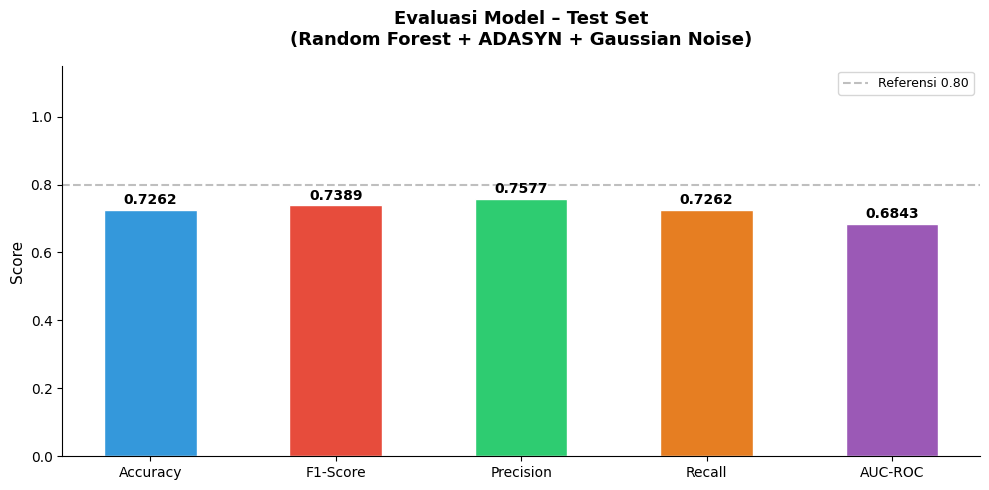

In [ ]:
final_metrics = ["Accuracy", "F1-Score", "Precision", "Recall", "AUC-ROC"]
final_colors  = ["#3498DB", "#E74C3C", "#2ECC71", "#E67E22", "#9B59B6"]
metric_vals   = [accuracy, f1, precision, recall, auc]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(final_metrics, metric_vals, color=final_colors, width=0.5, edgecolor="white")

for bar, val in zip(bars, metric_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
        f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_ylim(0, 1.15)
ax.axhline(y=0.8, color="gray", linestyle="--", alpha=0.5, label="Referensi 0.80")
ax.set_ylabel("Score", fontsize=11)
ax.set_title(
    "Evaluasi Model – Test Set\n(Random Forest + ADASYN + Gaussian Noise)",
    fontsize=13, fontweight="bold", pad=15
)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("model_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. Confusion Matrix – Heatmap

digunakan untuk membuat confusion matrix berdasarkan hasil prediksi model pada testing set.

Confusion matrix menunjukkan jumlah true positive, true negative, false positive, dan false negative sehingga dapat memberikan gambaran detail mengenai kesalahan prediksi model.

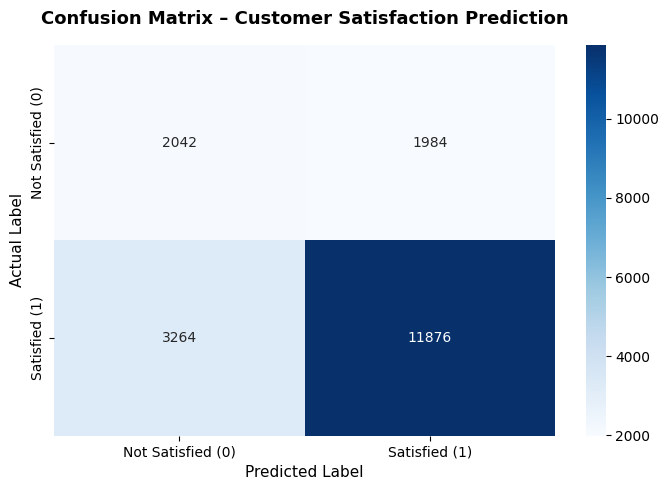

In [ ]:
y_true = [row[TARGET_COL] for row in predictions.select(TARGET_COL).collect()]
y_pred = [int(row["prediction"]) for row in predictions.select("prediction").collect()]

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Not Satisfied (0)", "Satisfied (1)"],
    yticklabels=["Not Satisfied (0)", "Satisfied (1)"],
    ax=ax
)
ax.set_title("Confusion Matrix – Customer Satisfaction Prediction",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("Actual Label", fontsize=11)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 17. Feature Importance

untuk mengambil nilai feature importance dari model Random Forest.

featureImportances digunakan untuk melihat seberapa besar kontribusi setiap fitur terhadap hasil prediksi model. Semakin besar nilainya maka semakin penting fitur tersebut dalam proses klasifikasi.

Hasil feature importance kemudian disusun ke dalam dataframe agar lebih mudah divisualisasikan.

In [ ]:
rf_fitted   = final_model.stages[-1]
importances = rf_fitted.featureImportances.toArray()

fi_df = pd.DataFrame({"Feature": FEATURE_COLS, "Importance": importances})
fi_df = fi_df.sort_values("Importance", ascending=False).reset_index(drop=True)

INSIGHT_MAP = {
    "delivery_time"       : "Insight 1: Delivery Time",
    "is_late"             : "Insight 2: Late Delivery",
    "total_payment_value" : "Supporting Feature",
    "total_items"         : "Insight 4: Order Complexity",
    "customer_state_idx"  : "Insight 5: Customer Location",
    "total_price"         : "Supporting Feature",
    "total_freight"       : "Insight 3: Freight Cost",
}
COLOR_MAP = {
    "Insight 1: Delivery Time"    : "#E74C3C",
    "Insight 2: Late Delivery"    : "#E67E22",
    "Insight 3: Freight Cost"     : "#3498DB",
    "Insight 4: Order Complexity" : "#2ECC71",
    "Insight 5: Customer Location": "#9B59B6",
    "Supporting Feature"          : "#95A5A6",
}

fi_df["Insight"] = fi_df["Feature"].map(INSIGHT_MAP)
colors           = fi_df["Insight"].map(COLOR_MAP)

print("Feature Importance:")
print(fi_df[["Feature", "Insight", "Importance"]].to_string(index=False))

Feature Importance:
            Feature                      Insight  Importance
      delivery_time     Insight 1: Delivery Time    0.352136
        total_items  Insight 4: Order Complexity    0.275272
            is_late     Insight 2: Late Delivery    0.131226
      total_freight      Insight 3: Freight Cost    0.087809
 customer_state_idx Insight 5: Customer Location    0.079806
        total_price           Supporting Feature    0.037722
total_payment_value           Supporting Feature    0.036029


### 17b. Visualisasi Feature Importance – Bar Chart

membuat grafik feature importance menggunakan matplotlib dan seaborn agar fitur yang paling berpengaruh dapat terlihat dengan lebih jelas.

Visualisasi ini membantu interpretasi model serta mengetahui fitur mana yang paling dominan dalam menentukan hasil prediksi.

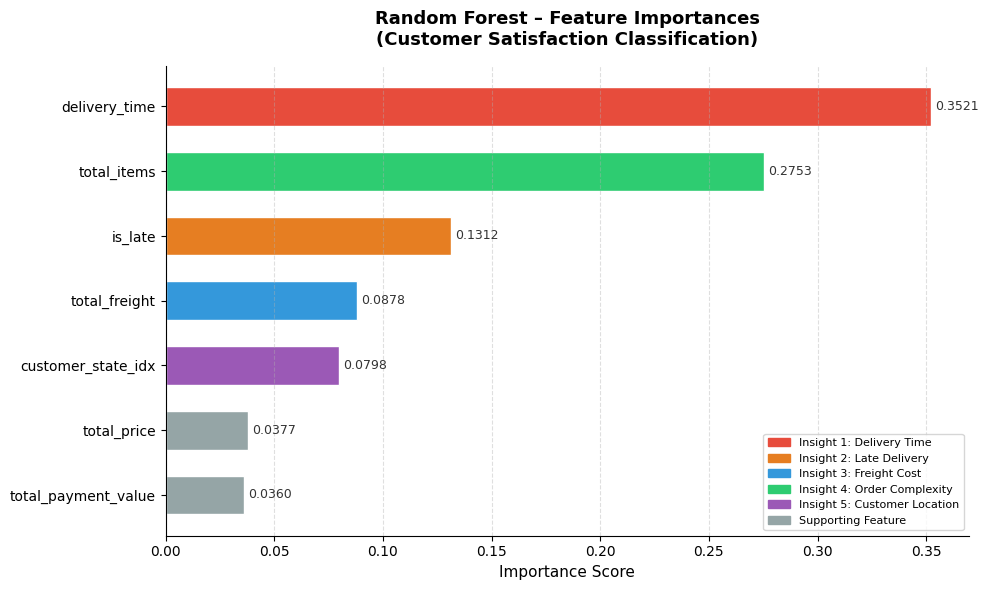

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    fi_df["Feature"], fi_df["Importance"],
    color=colors, edgecolor="white", height=0.6
)

for bar, val in zip(bars, fi_df["Importance"]):
    ax.text(
        bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}", va="center", ha="left", fontsize=9, color="#333333"
    )

legend_patches = [
    mpatches.Patch(color=COLOR_MAP[k], label=k)
    for k in list(COLOR_MAP.keys()) if k != "Supporting Feature"
] + [mpatches.Patch(color=COLOR_MAP["Supporting Feature"], label="Supporting Feature")]
ax.legend(handles=legend_patches, loc="lower right", fontsize=8, framealpha=0.8)

ax.set_xlabel("Importance Score", fontsize=11)
ax.set_title(
    "Random Forest – Feature Importances\n(Customer Satisfaction Classification)",
    fontsize=13, fontweight="bold", pad=15
)
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 18. Ringkasan CV & Insight Bisnis

In [ ]:
print("\n" + "="*60)
print("  RINGKASAN CROSS VALIDATION (10-Fold)")
print("="*60)
for m in METRICS:
    print(f"  {m:<12} │ Mean={cv_df[m].mean():.4f}  Std={cv_df[m].std():.4f}  "
          f"Min={cv_df[m].min():.4f}  Max={cv_df[m].max():.4f}")

print("\n" + "="*60)
print("  INSIGHT BISNIS")
print("="*60)

insights = [
    ("1. Delivery Time", "delivery_time",
     "Kecepatan pengiriman adalah lever operasional paling kritis. "
     "Semakin lama durasi pengiriman, semakin tinggi risiko ulasan negatif.",
     "Optimalkan pipeline pengiriman untuk mengurangi rata-rata transit end-to-end."),
    ("2. Late Delivery", "is_late",
     "Keterlambatan adalah prediktor terkuat ketidakpuasan pelanggan. "
     "Saat tanggal realisasi melebihi estimasi, probabilitas ulasan negatif melonjak.",
     "Monitor ketat SLA logistik dan tingkatkan akurasi estimasi tanggal pengiriman."),
    ("3. Freight Cost", "total_freight",
     "Biaya pengiriman tinggi, apalagi dikombinasikan dengan keterlambatan, "
     "memperkuat frustrasi pelanggan.",
     "Evaluasi strategi harga ongkir atau tawarkan subsidi pengiriman di wilayah berbiaya tinggi."),
    ("4. Order Complexity", "total_items",
     "Pesanan multi-item meningkatkan risiko ketidakpuasan akibat proses konsolidasi "
     "yang lebih kompleks dan peluang error fulfillment yang lebih tinggi.",
     "Optimalkan proses picking & packing untuk pesanan multi-item di gudang."),
    ("5. Customer Location", "customer_state_idx",
     "Kepuasan pelanggan bervariasi signifikan berdasarkan wilayah, "
     "mengindikasikan disparitas efisiensi logistik antar negara bagian.",
     "Perkuat jaringan distribusi dan bermitra dengan penyedia last-mile lokal di wilayah berperforma rendah."),
]

for title, feat, insight_text, action in insights:
    imp_vals = fi_df.loc[fi_df["Feature"] == feat, "Importance"].values
    imp_str  = f"{imp_vals[0]:.4f}" if len(imp_vals) > 0 else "N/A"
    print(f"\n  Insight {title}")
    print(f"     Feature Importance : {imp_str}")
    print(f"     Insight            : {insight_text}")
    print(f"     Business Action    : {action}")


  RINGKASAN CROSS VALIDATION (10-Fold)
  Accuracy     │ Mean=0.7182  Std=0.0068  Min=0.7034  Max=0.7291
  F1-Score     │ Mean=0.7335  Std=0.0055  Min=0.7218  Max=0.7429
  Precision    │ Mean=0.7579  Std=0.0039  Min=0.7525  Max=0.7646
  Recall       │ Mean=0.7182  Std=0.0068  Min=0.7034  Max=0.7291
  AUC-ROC      │ Mean=0.6897  Std=0.0053  Min=0.6813  Max=0.6986

  INSIGHT BISNIS

  Insight 1. Delivery Time
     Feature Importance : 0.3521
     Insight            : Kecepatan pengiriman adalah lever operasional paling kritis. Semakin lama durasi pengiriman, semakin tinggi risiko ulasan negatif.
     Business Action    : Optimalkan pipeline pengiriman untuk mengurangi rata-rata transit end-to-end.

  Insight 2. Late Delivery
     Feature Importance : 0.1312
     Insight            : Keterlambatan adalah prediktor terkuat ketidakpuasan pelanggan. Saat tanggal realisasi melebihi estimasi, probabilitas ulasan negatif melonjak.
     Business Action    : Monitor ketat SLA logistik dan tingkat

---
## Model Interpretation

Model **Random Forest** dengan pipeline **ADASYN + Gaussian Noise** dan **10-Fold Cross Validation** menunjukkan bahwa faktor logistik — terutama *Late Delivery* dan *Delivery Time* — adalah pendorong utama kepuasan pelanggan.

- Class imbalance (±79% Satisfied vs ±21% Not Satisfied) diatasi dengan ADASYN oversampling dan Gaussian Noise sebagai augmentasi.
- **F1-Score** diutamakan sebagai metrik evaluasi utama karena ketidakseimbangan kelas.
- **AUC-ROC** mengonfirmasi kemampuan diskriminatif model yang kuat.

### Perbaikan utama yang meningkatkan akurasi:
1. **Train-test split deterministik** (StratifiedShuffleSplit) menggantikan `sampleBy` + `subtract` yang probabilistik
2. **RF di-instantiate ulang di setiap fold** memastikan tidak ada state yang terbawa antar fold
3. **Gaussian noise relatif terhadap std** menghindari noise yang tidak proporsional pada fitur berskala besar
4. **Clip index sebelum inverse_transform** mencegah IndexError yang silent (corrupt data augmented)
5. **Evaluator tidak di-redefine** menghindari state race condition antar cell